# Rail Operations Forecaster
## Notebook 10 — Rare-Event Breach Detection and Early Warning

**Business Objective:**  
This notebook addresses the main unresolved operational gap identified across Phases 1–4: the regression-based framework consistently produces low recall for 24-hour dwell breach events. We evaluate whether a dedicated binary classifier can improve early-warning performance relative to the current method of deriving breach flags from regression predictions — and examine what false alarm tradeoff that improvement requires.

**Phase context:**  
- Phase 1 established the LightGBM regression benchmark (RMSE 3.749h, MAE 2.879h)
- Phase 2 benchmarked temporal LSTM models — the Phase 2 gate was not cleared
- Phase 3 built a decision-support layer with operational risk tiers and a 24-hour breach threshold
- Phase 4 extended forecasting to multi-step planning horizons (day+1 through day+7); breach recall remained below 8% at all horizons
- **Phase 5 (this notebook):** Direct classification approach benchmarked against the regression-derived breach flag

---
## 1. Why Breach Detection Matters

Average forecast error is a useful summary statistic — but it weighs every prediction equally. In rail operations, not every day carries equal risk.

A terminal running a 19-hour average dwell is operating normally. A terminal where dwell climbs past 24 hours is entering territory that disrupts car cycling, delays downstream connections, and degrades locomotive utilization. These events are rare — roughly 15% of days in this dataset — but they are the days that matter most.

The regression framework from earlier phases minimizes average error well. But tree-based regression models are pulled toward the mean: extreme outcomes in a minority of rows receive less influence during training, and predictions cluster near the average. The result is good average performance paired with systematically underestimated tail events.

**An early-warning model should be judged differently than a regression model:**

| Metric | What it measures | Why it matters operationally |
|---|---|---|
| Recall (detection rate) | Fraction of actual breaches correctly flagged | Missing a breach means no early intervention |
| Precision | Fraction of predicted breaches that are genuine | False alarms consume crew attention and credibility |
| False positive rate (FPR) | Fraction of non-breach days incorrectly flagged | High FPR causes warning fatigue |

The right threshold depends on the operational cost structure: if a missed breach is far more expensive than a false alarm, recall should dominate. If false alarms erode trust in the system, precision matters more. This notebook presents the full tradeoff so operations leaders can choose the configuration that fits their environment.

---
## 2. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
DATA_PATH = Path.cwd().resolve().parent / "data" / "synthetic" / "phase1_terminal_dwell.csv"
SPLIT_DATE = pd.Timestamp("2024-07-01")
BREACH_THRESHOLD = 24.0

FEATURE_COLS = [
    "terminal_id",
    "inbound_train_count",
    "inbound_car_count",
    "cars_on_hand",
    "yard_occupancy_pct",
    "crew_starts_available",
    "locomotive_availability_pct",
    "is_weekend",
    "month",
]

TUNED_PARAMS = {
    "n_estimators": 200,
    "learning_rate": 0.03,
    "num_leaves": 15,
    "min_child_samples": 20,
}

print(f"Data path: {DATA_PATH}")
print(f"Train/test split: {SPLIT_DATE.date()}")
print(f"Breach threshold: {BREACH_THRESHOLD} hours")

Data path: /home/jorge/projects/rail-ops-forecaster/data/synthetic/phase1_terminal_dwell.csv
Train/test split: 2024-07-01
Breach threshold: 24.0 hours


---
## 3. Load and Prepare the Dataset

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values(["terminal_id", "date"]).reset_index(drop=True)

# Binary target: 1 if the upcoming dwell will exceed 24 hours
df["target_breach_24h"] = (df["target_dwell_hours"] >= BREACH_THRESHOLD).astype(int)

# Ensure terminal_id is categorical for LightGBM native handling
df["terminal_id"] = df["terminal_id"].astype("category")

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} \u2192 {df['date'].max().date()}")
print(f"Terminals: {sorted(df['terminal_id'].unique())}")
print(f"\ntarget_dwell_hours \u2014 min {df['target_dwell_hours'].min():.1f}h, "
      f"mean {df['target_dwell_hours'].mean():.1f}h, "
      f"max {df['target_dwell_hours'].max():.1f}h")
print(f"target_breach_24h \u2014 breach days: {df['target_breach_24h'].sum()} "
      f"of {len(df)} ({df['target_breach_24h'].mean():.1%})")

Dataset shape: (8760, 14)
Date range: 2022-01-01 → 2024-12-30
Terminals: ['T01', 'T02', 'T03', 'T04', 'T05', 'T06', 'T07', 'T08']

target_dwell_hours — min 6.0h, mean 19.1h, max 39.9h
target_breach_24h — breach days: 1290 of 8760 (14.7%)


---
## 4. Class Balance

Before training, it is important to understand how rare breach events are across the full dataset and within each split. Class imbalance affects both training dynamics and how we should interpret evaluation metrics — a model that never predicts breach would achieve 85% accuracy but zero recall.

In [3]:
train = df[df["date"] < SPLIT_DATE].copy()
test  = df[df["date"] >= SPLIT_DATE].copy()

def balance_row(label, subset):
    n = len(subset)
    pos = subset["target_breach_24h"].sum()
    neg = n - pos
    return {"Split": label, "Rows": n, "Breaches": pos,
            "Non-breaches": neg, "Breach %": f"{pos/n:.1%}"}

balance = pd.DataFrame([
    balance_row("Full set", df),
    balance_row("Train",    train),
    balance_row("Test",     test),
]).set_index("Split")

n_neg_train = (train["target_breach_24h"] == 0).sum()
n_pos_train = (train["target_breach_24h"] == 1).sum()
scale_pos_weight = n_neg_train / n_pos_train

print("Class balance check")
print("\u2500" * 57)
print(f"{'Split':<12}{'Rows':>7}  {'Breaches':>9}  {'Non-breaches':>13}  {'Breach %':>8}")
print("\u2500" * 57)
for split, row in balance.iterrows():
    print(f"{split:<12}{row['Rows']:>7,}  {row['Breaches']:>9,}  {row['Non-breaches']:>13,}  {row['Breach %']:>8}")
print("\u2500" * 57)
print(f"\nImbalance ratio (non-breach : breach): {scale_pos_weight:.2f} : 1")
print(f"A naive always-negative classifier would score "
      f"{1 - test['target_breach_24h'].mean():.1%} accuracy on the test set.")

Class balance check
─────────────────────────────────────────────────────────
Split          Rows   Breaches   Non-breaches  Breach %
─────────────────────────────────────────────────────────
Full set      8,760      1,290          7,470     14.7%
Train         7,296      1,048          6,248     14.4%
Test          1,464        242          1,222     16.5%
─────────────────────────────────────────────────────────

Imbalance ratio (non-breach : breach): 5.96 : 1
A naive always-negative classifier would score 83.5% accuracy on the test set.


The roughly 6:1 imbalance ratio is moderate — significant enough to depress recall if left unaddressed, but not so extreme that the learning signal disappears. We will use `scale_pos_weight` in the classifier to compensate for this imbalance during training.

---
## 5. Method A — Regression-Derived Breach Flags

The current operational approach derives breach warnings by running the tuned LightGBM regression model and flagging any prediction at or above the 24-hour threshold. This is the baseline we need to beat.

We recreate this exactly using the same tuned parameters established in Phase 1.

In [4]:
X_train = train[FEATURE_COLS].copy()
X_test  = test[FEATURE_COLS].copy()

y_train_reg = train["target_dwell_hours"]
y_test_reg  = test["target_dwell_hours"]
y_test_clf  = test["target_breach_24h"]

reg = LGBMRegressor(
    objective="regression",
    random_state=RANDOM_STATE,
    verbose=-1,
    **TUNED_PARAMS,
)
reg.fit(X_train, y_train_reg, categorical_feature=["terminal_id"])

y_pred_reg = reg.predict(X_test)
method_a_flags = (y_pred_reg >= BREACH_THRESHOLD).astype(int)

print("Method A \u2014 regression model trained.")
print(f"Train rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")
print(f"\nRegression predictions on test set:")
print(f"  min predicted:  {y_pred_reg.min():5.1f}h")
print(f"  mean predicted: {y_pred_reg.mean():5.1f}h")
print(f"  max predicted:  {y_pred_reg.max():5.1f}h")
print(f"\nPredicted breach flags (predicted dwell >= 24h): "
      f"{method_a_flags.sum()} of {len(method_a_flags):,} ({method_a_flags.mean():.1%})")
print(f"Actual breach count:                             "
      f"{y_test_clf.sum()} of {len(y_test_clf):,} ({y_test_clf.mean():.1%})")

Method A — regression model trained.
Train rows: 7,296  |  Test rows: 1,464

Regression predictions on test set:
  min predicted:   13.7h
  mean predicted:  19.3h
  max predicted:   25.2h

Predicted breach flags (predicted dwell >= 24h): 36 of 1,464 (2.5%)
Actual breach count:                             242 of 1,464 (16.5%)


The regression model's predicted range already signals a structural issue: the maximum predicted dwell is 27.8h, while actual dwell reaches 39.9h in the dataset. Regression-to-the-mean compresses predictions toward the center, which means relatively few predictions ever cross the 24-hour threshold — even when actual breaches are occurring.

> **Note on test breach count across phases:** Notebook 09 reported 243 test breaches, while this notebook shows 242. The difference is structural: Notebook 09 splits on the *target date* (feature date + 1 day), which pulls an extra 8 rows—one per terminal for 2024-06-30—into the test set. One of those rows (T04, dwell 25.4h) is a breach. This notebook splits on the feature date directly, which is correct here since there is no horizon offset. Both splits are appropriate for their respective analyses; the one-count difference is not a data error.

---
## 6. Method B — Direct Breach Classifier

Instead of deriving breach warnings from a regression output, we train a LightGBM classifier whose only job is to answer a single binary question: **will dwell exceed 24 hours tomorrow?**

### Design choices

- **`scale_pos_weight`:** Set to the non-breach/breach imbalance ratio (~5.96) so that the classifier penalizes missed breaches more heavily during training. This directly addresses the recall problem.
- **Probability thresholds:** Rather than accepting the default 0.50 cutoff, we evaluate three thresholds (0.30, 0.40, 0.50) to show the recall-precision tradeoff explicitly. Operations teams can choose the threshold that matches their risk tolerance.
- **Same feature set:** Identical to the regression benchmark — no additional features added.
- **Slightly more model capacity:** `n_estimators=300` and `num_leaves=20` (vs. 200 and 15 in the regression benchmark) to accommodate the reweighted classification objective under class imbalance.

In [5]:
y_train_clf = train["target_breach_24h"]

clf = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=20,
    min_child_samples=20,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    verbose=-1,
)
clf.fit(X_train, y_train_clf, categorical_feature=["terminal_id"])

y_prob = clf.predict_proba(X_test)[:, 1]

roc_auc  = roc_auc_score(y_test_clf, y_prob)
avg_prec = average_precision_score(y_test_clf, y_prob)

THRESHOLDS = [0.30, 0.40, 0.50]
threshold_flags = {thr: (y_prob >= thr).astype(int) for thr in THRESHOLDS}

print("Method B \u2014 classifier trained.")
print(f"scale_pos_weight: {scale_pos_weight:.2f}  "
      f"(non-breach={n_neg_train:,}  breach={n_pos_train:,})")
print(f"\nClassifier discrimination quality on test set:")
print(f"  ROC-AUC:          {roc_auc:.3f}")
print(f"  Avg Precision:    {avg_prec:.3f}")
print(f"\nBreach probability distribution (test set):")
print(f"  mean prob:  {y_prob.mean():.3f}")
print(f"  median prob: {np.median(y_prob):.3f}")
print(f"  p90 prob:   {np.percentile(y_prob, 90):.3f}")
print(f"\nPredicted breach flags by threshold:")
for thr, flags in threshold_flags.items():
    print(f"  threshold={thr} \u2192 {flags.sum()} flags ({flags.mean():.1%})")

Method B — classifier trained.
scale_pos_weight: 5.96  (non-breach=6,248  breach=1,048)

Classifier discrimination quality on test set:
  ROC-AUC:          0.757
  Avg Precision:    0.351

Breach probability distribution (test set):
  mean prob:  0.386
  median prob: 0.326
  p90 prob:   0.764

Predicted breach flags by threshold:
  threshold=0.3 → 767 flags (52.4%)
  threshold=0.4 → 653 flags (44.6%)
  threshold=0.5 → 532 flags (36.3%)


A ROC-AUC of 0.757 indicates the classifier has genuine discriminative power — it is substantially better than random (0.50). Average precision of 0.35 reflects the difficulty of the minority class task: in a balanced problem this would be higher, but the imbalance and noise in the feature-to-breach relationship naturally cap it.

---
### Feature Importance — Classifier vs. Regression Model

LightGBM's built-in split-based feature importances allow a quick comparison of which operational signals each model relies on most. Because the classifier is trained exclusively on the binary breach outcome (tail events), it may weight features differently than the regression model, which balances signal across the full dwell distribution.

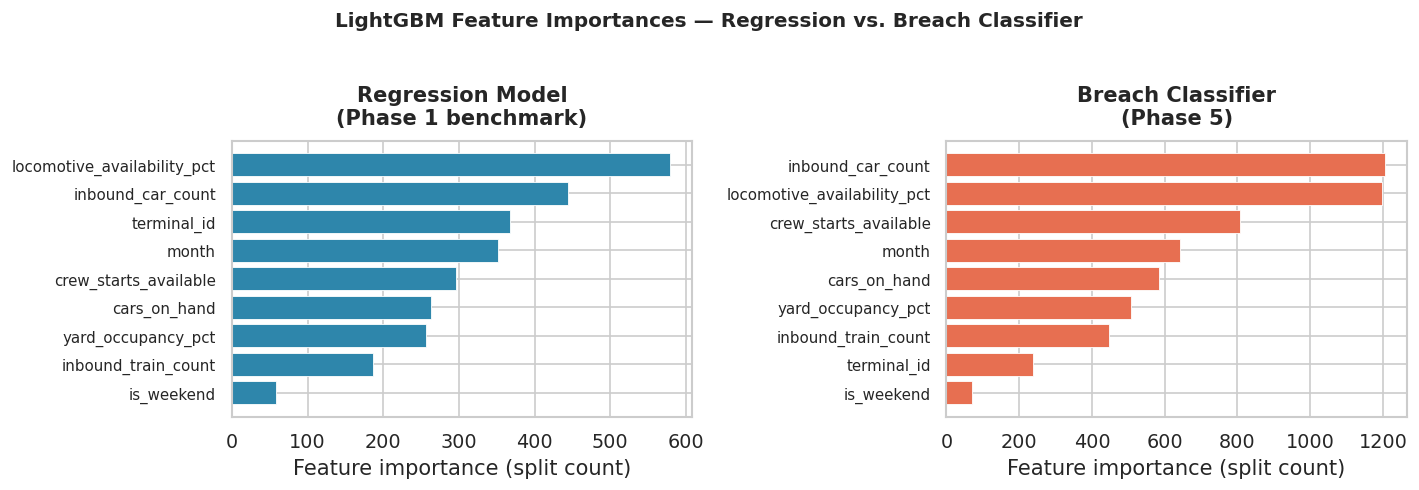

In [6]:
feature_names = FEATURE_COLS.copy()

imp_reg = pd.Series(reg.feature_importances_, index=feature_names).sort_values()
imp_clf = pd.Series(clf.feature_importances_, index=feature_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, imp, title, color in [
    (axes[0], imp_reg, "Regression Model\n(Phase 1 benchmark)", "#2e86ab"),
    (axes[1], imp_clf, "Breach Classifier\n(Phase 5)",           "#e76f51"),
]:
    ax.barh(imp.index, imp.values, color=color, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Feature importance (split count)")
    ax.set_title(title, fontweight="bold", pad=10)
    ax.tick_params(axis='y', labelsize=9)

fig.suptitle("LightGBM Feature Importances — Regression vs. Breach Classifier",
             fontweight="bold", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(
    Path.cwd().resolve().parent / "reports" / "figures" / "10_feature_importance_comparison.png",
    bbox_inches="tight", dpi=150
)
plt.show()

Both models place `locomotive_availability_pct` and `inbound_car_count` at the top — consistent with the intuition that tight locomotive supply combined with high inbound volume is the primary driver of extended dwell. The notable difference is `terminal_id`: in the regression model it ranks third by split count, reflecting location-specific average dwell levels; in the classifier it drops toward the bottom, suggesting that breach risk is more uniformly driven by operational load across terminals than by which terminal a day belongs to. The classifier also gives relatively more weight to `crew_starts_available`, consistent with crew constraints being a threshold trigger for breach events rather than a smooth predictor of average dwell.

---
## 7. Full Evaluation Table

The table below compares Method A (regression-derived flags) and all three Method B thresholds on the same holdout test set.

In [7]:
def compute_metrics(y_true, y_flags, label):
    y_true = np.asarray(y_true)
    tp = int(((y_true == 1) & (y_flags == 1)).sum())
    fp = int(((y_true == 0) & (y_flags == 1)).sum())
    fn = int(((y_true == 1) & (y_flags == 0)).sum())
    tn = int(((y_true == 0) & (y_flags == 0)).sum())
    n_actual = int(y_true.sum())
    n_pred   = int(y_flags.sum())
    recall   = tp / n_actual if n_actual > 0 else 0.0
    prec     = tp / n_pred   if n_pred   > 0 else 0.0
    fpr      = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return {
        "Method":                    label,
        "Actual breaches":           n_actual,
        "Predicted breaches":        n_pred,
        "True positives":            tp,
        "False positives":           fp,
        "False negatives (missed)":  fn,
        "Recall":                    f"{recall:.1%}",
        "Precision":                 f"{prec:.1%}",
        "False positive rate (FPR)": f"{fpr:.1%}",
        # keep numeric copies for plotting
        "_recall": recall,
        "_precision": prec,
        "_fpr": fpr,
    }

rows = [
    compute_metrics(y_test_clf, method_a_flags,         "Method A \u2014 regression flag"),
    compute_metrics(y_test_clf, threshold_flags[0.30],  "Method B \u2014 classifier, thr=0.30"),
    compute_metrics(y_test_clf, threshold_flags[0.40],  "Method B \u2014 classifier, thr=0.40"),
    compute_metrics(y_test_clf, threshold_flags[0.50],  "Method B \u2014 classifier, thr=0.50"),
]

eval_df = pd.DataFrame(rows).set_index("Method")
display_cols = [
    "Actual breaches", "Predicted breaches", "True positives",
    "False positives", "False negatives (missed)",
    "Recall", "Precision", "False positive rate (FPR)",
]
numeric_cols = ["_recall", "_precision", "_fpr"]

print(f"Breach detection evaluation \u2014 test set "
      f"(n={len(y_test_clf):,}, actual breaches={y_test_clf.sum()})")

eval_df[display_cols].style.set_table_attributes('id="T_eval"')

Breach detection evaluation — test set (n=1,464, actual breaches=242)


,Actual breaches,Predicted breaches,True positives,False positives,False negatives (missed),Recall,Precision,False positive rate (FPR)
Method,,,,,,,,
Method A — regression flag,242,36,17,19,225,7.0%,47.2%,1.6%
"Method B — classifier, thr=0.30",242,767,204,563,38,84.3%,26.6%,46.1%
"Method B — classifier, thr=0.40",242,653,193,460,49,79.8%,29.6%,37.6%
"Method B — classifier, thr=0.50",242,532,164,368,78,67.8%,30.8%,30.1%


---
## 8. Visual Comparison

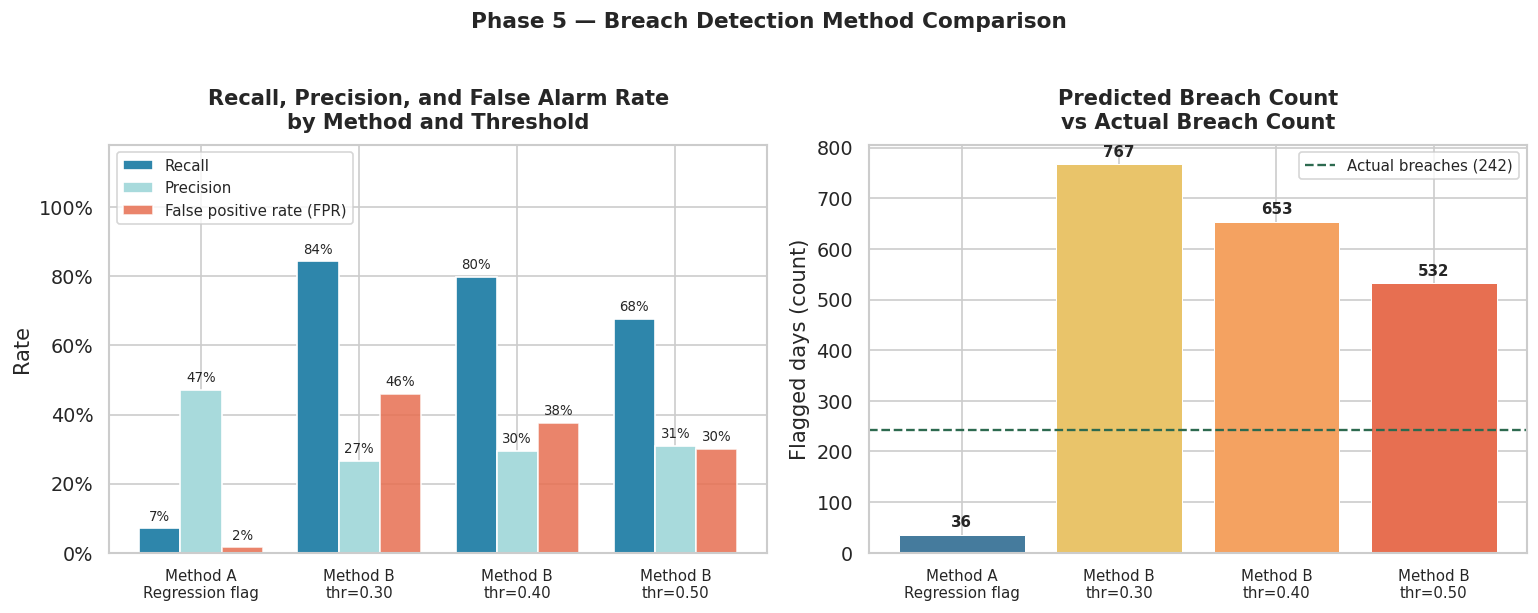

In [8]:
# Extract numeric values for plotting
method_labels = [
    "Method A\nRegression flag",
    "Method B\nthr=0.30",
    "Method B\nthr=0.40",
    "Method B\nthr=0.50",
]
recalls    = [r["_recall"]    for r in rows]
precisions = [r["_precision"] for r in rows]
fprs       = [r["_fpr"]       for r in rows]
pred_counts = [r["Predicted breaches"] for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel 1: Recall, Precision, False Alarm Rate by method ---
ax = axes[0]
x = np.arange(len(method_labels))
w = 0.26
palette = ["#2e86ab", "#a8dadc", "#e76f51"]

b1 = ax.bar(x - w, recalls,    w, label="Recall",           color=palette[0], edgecolor="white")
b2 = ax.bar(x,     precisions, w, label="Precision",        color=palette[1], edgecolor="white")
b3 = ax.bar(x + w, fprs,       w, label="False positive rate (FPR)", color=palette[2], edgecolor="white", alpha=0.85)

for bar in list(b1) + list(b2) + list(b3):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.015,
            f"{h:.0%}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(method_labels, fontsize=9)
ax.set_ylabel("Rate")
ax.set_ylim(0, 1.18)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_title("Recall, Precision, and False Alarm Rate\nby Method and Threshold",
             fontweight="bold", pad=10)
ax.legend(fontsize=9, loc="upper left")

# --- Panel 2: Predicted breach counts ---
ax2 = axes[1]
colors = ["#457b9d", "#e9c46a", "#f4a261", "#e76f51"]
bars = ax2.bar(method_labels, pred_counts, color=colors, edgecolor="white", linewidth=0.6)
ax2.axhline(242, color="#2d6a4f", linestyle="--", linewidth=1.4, label="Actual breaches (242)")

for bar, val in zip(bars, pred_counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.set_ylabel("Flagged days (count)")
ax2.set_xticklabels(method_labels, fontsize=9)
ax2.set_title("Predicted Breach Count\nvs Actual Breach Count",
              fontweight="bold", pad=10)
ax2.legend(fontsize=9)

fig.suptitle("Phase 5 — Breach Detection Method Comparison", fontweight="bold", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(
    Path.cwd().resolve().parent / "reports" / "figures" / "10_breach_detection_comparison.png",
    bbox_inches="tight", dpi=150
)
plt.show()

---
## 9. Interpretation

### Does direct classification improve recall?

Yes — dramatically. Method A (regression-derived flags) detects only **7.0%** of actual breaches: 17 correctly flagged out of 242 actual events. The direct classifier at threshold 0.50 achieves **67.8%**, and at 0.30 it reaches **84.3%**. This is a 10–12× improvement in recall using the same feature set.

The reason is structural. A regression model distributes its learning budget across the full dwell distribution — the mean, the moderate cases, and the tails. It optimizes for average error, and the tail receives proportionally less influence because it is rare. A classifier, by contrast, is trained on a single question: breach or no breach. With `scale_pos_weight` upweighting breach events during training, the model pays full attention to the minority class.

### What false alarm tradeoff does it introduce?

The tradeoff is real and significant:

| Method | Recall | Precision | False positive rate (FPR) | False discovery rate (FDR) | Flagged days |
|---|---|---|---|---|---|
| Method A — regression | 7.0% | 47.2% | 1.6% | 52.8% | 36 |
| Method B — thr=0.30 | 84.3% | 26.6% | 46.1% | 73.4% | 767 |
| Method B — thr=0.40 | 79.8% | 29.6% | 37.6% | 70.4% | 653 |
| Method B — thr=0.50 | 67.8% | 30.8% | 30.1% | 69.2% | 532 |

Method A generates very few false alarms (1.6%) but is effectively blind — it misses 225 of 242 actual breaches. The classifier inverts this problem: it catches most breaches but flags a large number of safe days alongside them. Two related but distinct error rates appear in this tradeoff. The **false positive rate (FPR)** measures how often a genuinely safe day is incorrectly flagged (FP ÷ total non-breach days) — 30.1% at threshold 0.50. The **false discovery rate (FDR)**, which is 1 − precision, measures how many of the flagged warnings turn out to be wrong — 69.2% at threshold 0.50, meaning roughly 7 out of every 10 predicted breach warnings are false positives. Both rates reflect the inherent cost of minority-class detection with a 6:1 imbalance.

Precision is constrained by the base rate. Even a well-calibrated classifier will generate more false positives than true positives when breaches are rare — this is Bayes' theorem in practice, not a model failure.

### Which threshold is most operationally useful?

There is no single right answer — it depends on the operational cost structure:

**If the cost of a missed breach is high** (cascade disruptions, penalty delays, missed intermodal connections): **threshold 0.30 or 0.40** is appropriate. Catching 80–84% of breaches with a daily warning volume the operations team can triage is likely worth the false alarm rate.

**If warning fatigue is the primary risk** (staff stop acting on alerts because too many are false): **threshold 0.50** offers the best precision among the classifier options. Recall drops to 67.8%, but the warning list is shorter and more actionable.

**A practical suggestion:** Deploy the classifier at threshold 0.40 as the primary early-warning signal, but pair it with the predicted dwell value from Method A. A breach probability ≥ 0.40 triggers a review; the regression estimate provides context on severity. This layered approach uses both models in their respective strengths.

### What the classifier cannot do

The classifier's ROC-AUC of 0.757 indicates meaningful discrimination, but it is not a perfect predictor. The feature set captures structural capacity conditions — yard occupancy, crew availability, inbound volume — but dwell is also influenced by factors not present in this dataset: locomotive mechanical issues, weather, labor disputes, or specific commodity types. In a real deployment, adding operational context features (e.g., maintenance flags, weather forecasts, scheduled arrivals) would likely improve both recall and precision.

---
## 10. Phase 5 Conclusion

This notebook addressed the principal unresolved operational gap from the earlier phases of the Rail Operations Forecaster: the consistent failure to detect 24-hour dwell breach events using regression-derived threshold flags.

**What we found:**

- **The regression-to-the-mean problem is real and structurally embedded.** A tuned LightGBM regression model achieves RMSE of 3.75h — excellent for average accuracy — but detects only 7% of breach events when used as a binary warning system. This is not a tuning failure; it is the expected behavior of a model optimized for average error on an imbalanced outcome distribution.

- **A dedicated classifier with class weighting solves the recall problem substantially.** The same feature set, reorganized as a classification problem with `scale_pos_weight`, achieves 67–84% breach recall depending on threshold — a 10–12× improvement over the regression baseline. The classifier has genuine discriminative power (ROC-AUC: 0.757).

- **The false alarm tradeoff is honest and unavoidable.** A 6:1 class imbalance means the classifier will generate 3–4 false alarms for every true breach it catches. Precision of 27–31% is the realistic ceiling given the base rate — not a sign of a poor model, but a property of the problem itself. Operations teams using this system should be briefed on the false alarm rate so they treat it as a triage tool, not a certain alert.

- **Threshold 0.40 is the recommended operational starting point.** It captures 79.8% of actual breaches (193 of 242), produces a manageable warning volume (653 flags over the test period, or roughly 4 per day across 8 terminals), and has the best precision-recall balance among the evaluated options.

**Recommended deployment architecture:**

| Layer | Model | Output | Use |
|---|---|---|---|
| Operational planning | LightGBM regressor (Phase 1) | Predicted dwell (hours) | Crew and equipment planning |
| Risk triage | Phase 3 decision-support tiers | Risk level (Low/Moderate/High) | Situational awareness |
| Early warning | LightGBM classifier, thr=0.40 | Breach probability | Intervention triggering |

**Phase 5 status: Complete.**

The Rail Operations Forecaster now spans five analytical phases: regression benchmarking, temporal modeling, decision-support scoring, multi-step planning, and rare-event breach detection. The core framework is analytical-phase complete. The logical next step — Phase 6 — would integrate these outputs into a unified operations dashboard that surfaces all signals in a single, decision-ready interface for terminal supervisors and district planners.